# Mini-Projet : A* et Chaînes de Markov


In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')

from grid   import make_easy_grid, make_medium_grid, make_hard_grid
from astar  import graph_search
from markov import make_policy, build_transition_matrix, comm_classes, expected_steps, absorb_prob, monte_carlo


In [2]:
def show_grid(ax, env, path, title, path2=None):
    import numpy as np
    W, H = env.width, env.height
    img = np.ones((H, W, 3))
    for (x,y) in env.obstacles:
        img[y,x] = [0.25, 0.25, 0.3]
    ax.imshow(img, origin='upper')
    if path:
        ax.plot([s[0] for s in path], [s[1] for s in path],
                'b-', lw=2, marker='.', ms=3, label='A*')
    if path2:
        ax.plot([s[0] for s in path2], [s[1] for s in path2],
                'r--', lw=2, marker='.', ms=3, label='UCS')
    ax.plot(*env.start, 'go', ms=8, label='start')
    ax.plot(*env.goal,  'y*', ms=10, label='goal')
    ax.set_title(title, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=6)


## E1 — comparaison UCS / Greedy / A*


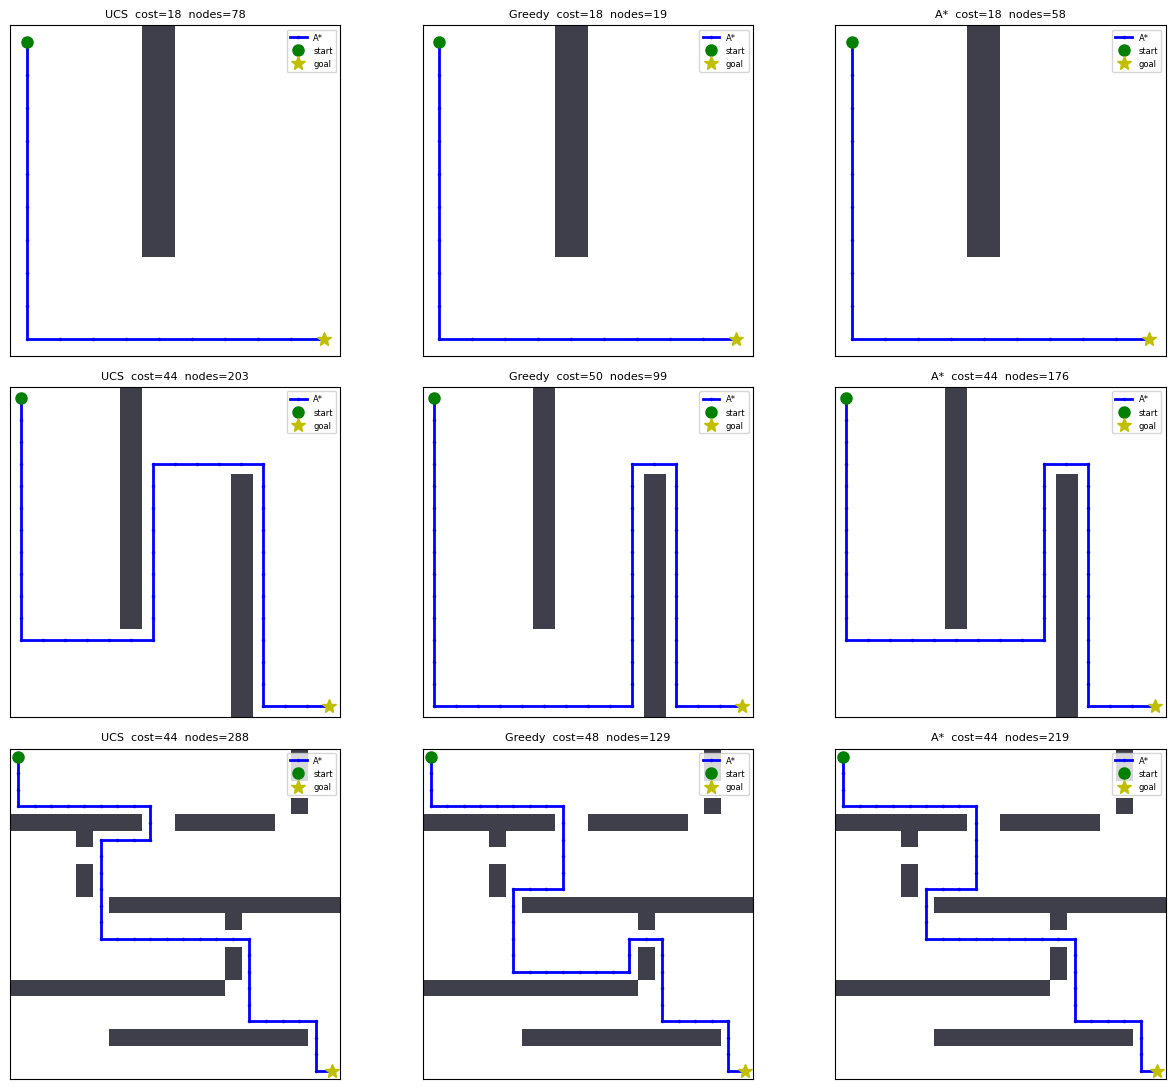

grid           algo      cost   nodes       ms
easy 10x10     UCS         18      78     3.61
easy 10x10     Greedy      18      19     0.61
easy 10x10     A*          18      58     0.99

medium 15x15   UCS         44     203     3.09
medium 15x15   Greedy      50      99     0.89
medium 15x15   A*          44     176     1.28

hard 20x20     UCS         44     288     1.97
hard 20x20     Greedy      48     129    39.59
hard 20x20     A*          44     219     6.23



In [3]:
envs  = [('easy 10x10',   make_easy_grid()),
          ('medium 15x15', make_medium_grid()),
          ('hard 20x20',   make_hard_grid())]
algos = ['UCS', 'Greedy', 'A*']

fig, axs = plt.subplots(3, 3, figsize=(13, 11))

for i, (name, env) in enumerate(envs):
    for j, algo in enumerate(algos):
        r = graph_search(env, search_type=algo)
        t = algo + '  cost=' + str(int(r['cost'])) + '  nodes=' + str(r['nodes_developed'])
        show_grid(axs[i][j], env, r['path'] or [], t)

plt.tight_layout()
plt.savefig('../results/E1_algorithm_comparison/E1_grid_paths.png', dpi=120)
plt.show()

# print table
print(f"{'grid':<14} {'algo':<8} {'cost':>5} {'nodes':>7} {'ms':>8}")
for name, env in envs:
    for algo in algos:
        r = graph_search(env, search_type=algo)
        print(f"{name:<14} {algo:<8} {r['cost']:>5.0f} {r['nodes_developed']:>7} {r['time']*1000:>8.2f}")
    print()


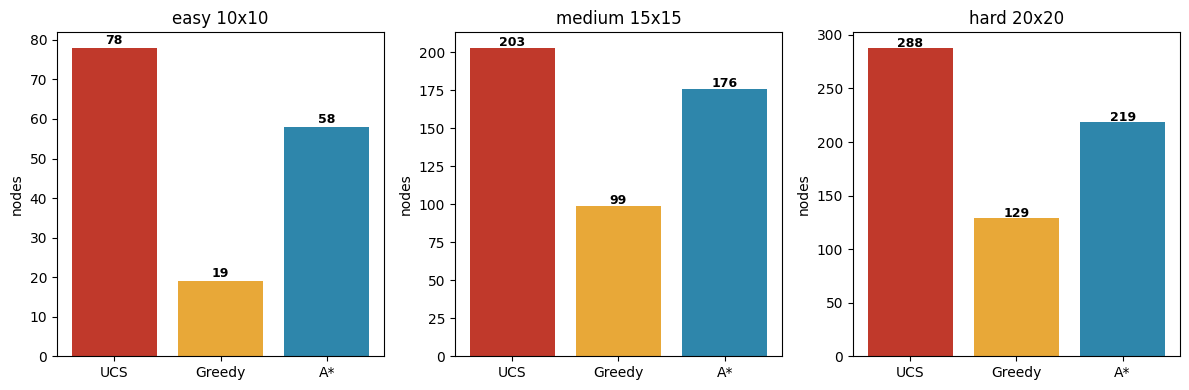

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for i, (name, env) in enumerate(envs):
    counts = [graph_search(env, search_type=a)['nodes_developed'] for a in algos]
    axs[i].bar(algos, counts, color=['#c0392b','#e8a838','#2e86ab'])
    for bar, v in zip(axs[i].patches, counts):
        axs[i].text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+1, str(v),
                    ha='center', fontsize=9, fontweight='bold')
    axs[i].set_title(name)
    axs[i].set_ylabel('nodes')

plt.tight_layout()
plt.savefig('../results/E1_algorithm_comparison/E1_nodes_barchart.png', dpi=120)
plt.show()


## E2 — impact de epsilon sur P(goal)


eps=0.0  P_matrix=1.0000  P_mc=1.0000  avg=44.0
eps=0.1  P_matrix=0.0334  P_mc=0.7492  avg=49.4
eps=0.2  P_matrix=0.0007  P_mc=0.6706  avg=61.9
eps=0.3  P_matrix=0.0000  P_mc=0.6941  avg=84.3


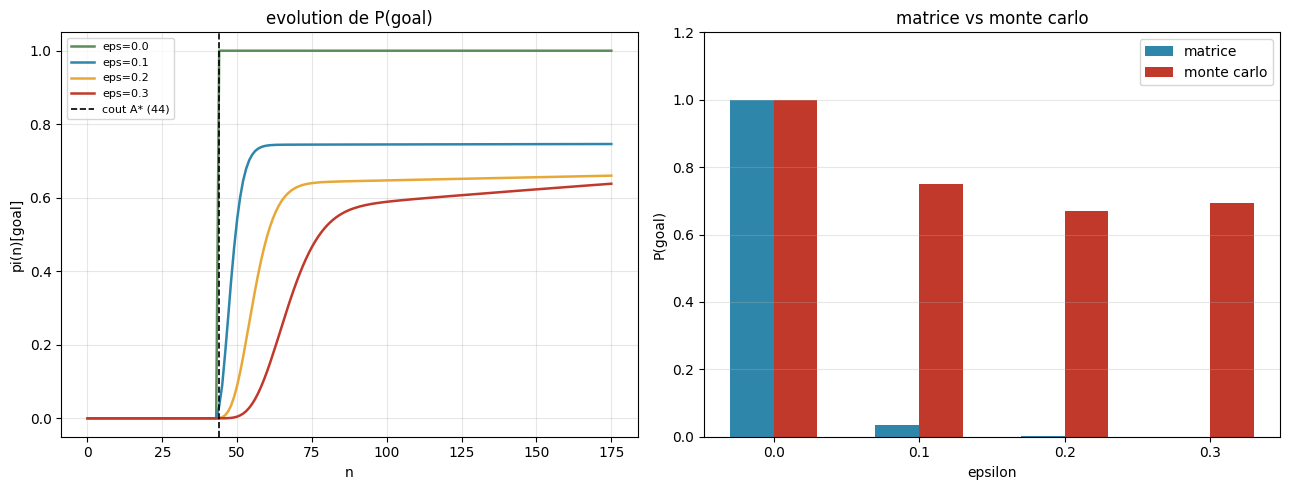

In [5]:
env = make_medium_grid()
r   = graph_search(env, search_type='A*')
pol = make_policy(r['path'], env)
opt = r['cost']

eps_list = [0.0, 0.1, 0.2, 0.3]
colors   = ['#5b8c5a','#2e86ab','#e8a838','#c0392b']
steps    = range(0, opt*4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

pm_vals, mc_vals = [], []
for eps, col in zip(eps_list, colors):
    P, st, sid = build_transition_matrix(env, pol, eps=eps)
    pi0 = np.zeros(len(st)); pi0[sid[env.start]] = 1.0
    gi  = sid[env.goal]
    probs = [float((pi0 @ np.linalg.matrix_power(P,n))[gi]) for n in steps]
    pm_vals.append(probs[opt])
    rate, avg, _ = monte_carlo(P, st, env.start, env.goal, N=8000, max_steps=opt*6)
    mc_vals.append(rate)
    print(f'eps={eps}  P_matrix={probs[opt]:.4f}  P_mc={rate:.4f}  avg={avg:.1f}')
    ax1.plot(list(steps), probs, color=col, lw=1.8, label=f'eps={eps}')

ax1.axvline(opt, color='k', ls='--', lw=1.2, label=f'cout A* ({opt})')
ax1.set_xlabel('n'); ax1.set_ylabel('pi(n)[goal]')
ax1.set_title('evolution de P(goal)')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

x = np.arange(len(eps_list)); w = 0.3
ax2.bar(x-w/2, pm_vals, w, label='matrice', color='#2e86ab')
ax2.bar(x+w/2, mc_vals, w, label='monte carlo', color='#c0392b')
ax2.set_xticks(x); ax2.set_xticklabels([str(e) for e in eps_list])
ax2.set_xlabel('epsilon'); ax2.set_ylabel('P(goal)'); ax2.set_ylim(0,1.2)
ax2.set_title('matrice vs monte carlo')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/E2_epsilon_impact/E2_epsilon_impact.png', dpi=120)
plt.show()


## E3 — h=0 vs heuristique Manhattan


easy  UCS=78  A*=58  -25.6%
medium  UCS=203  A*=176  -13.3%
hard  UCS=288  A*=219  -24.0%


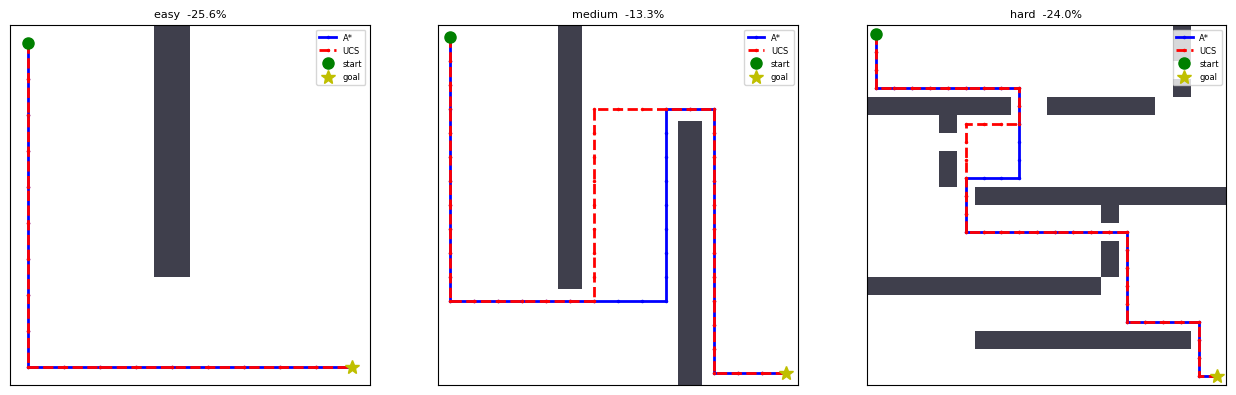

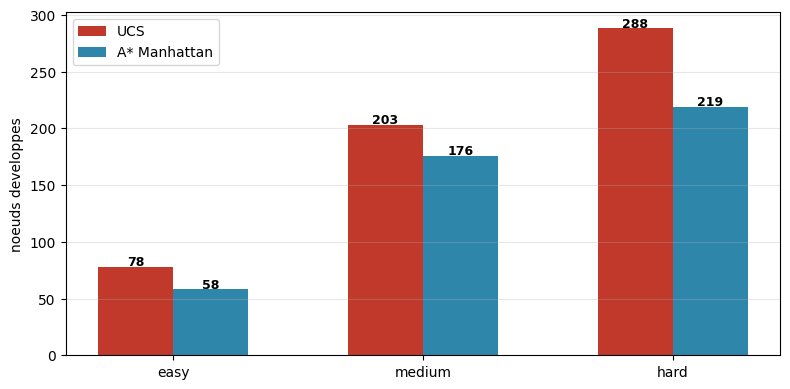

In [6]:
envs = [('easy',   make_easy_grid()),
         ('medium', make_medium_grid()),
         ('hard',   make_hard_grid())]

fig, axs = plt.subplots(1, 3, figsize=(13, 4))

nu, na = [], []
for i, (name, env) in enumerate(envs):
    ru = graph_search(env, search_type='UCS')
    ra = graph_search(env, search_type='A*')
    red = (1 - ra['nodes_developed']/ru['nodes_developed'])*100
    nu.append(ru['nodes_developed'])
    na.append(ra['nodes_developed'])
    print(f"{name}  UCS={ru['nodes_developed']}  A*={ra['nodes_developed']}  -{red:.1f}%")
    t = name + '  -' + str(round(red,1)) + '%'
    show_grid(axs[i], env, ra['path'], t, path2=ru['path'])

plt.tight_layout()
plt.savefig('../results/E3_heuristic_comparison/E3_grid_paths.png', dpi=120)
plt.show()

fig2, ax = plt.subplots(figsize=(8, 4))
names = [e[0] for e in envs]
x = np.arange(len(names)); w = 0.3
b1 = ax.bar(x-w/2, nu, w, label='UCS',         color='#c0392b')
b2 = ax.bar(x+w/2, na, w, label='A* Manhattan', color='#2e86ab')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            int(b.get_height()), ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('noeuds developpes'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/E3_heuristic_comparison/E3_heuristics_barchart.png', dpi=120)
plt.show()


## E4 — A* pondere (weighted A*)


W=1.0  cost=44  nodes=219  subopt=0.0%
W=1.2  cost=44  nodes=181  subopt=0.0%
W=1.5  cost=44  nodes=181  subopt=0.0%
W=2.0  cost=48  nodes=144  subopt=9.1%
W=3.0  cost=48  nodes=138  subopt=9.1%
W=5.0  cost=48  nodes=135  subopt=9.1%


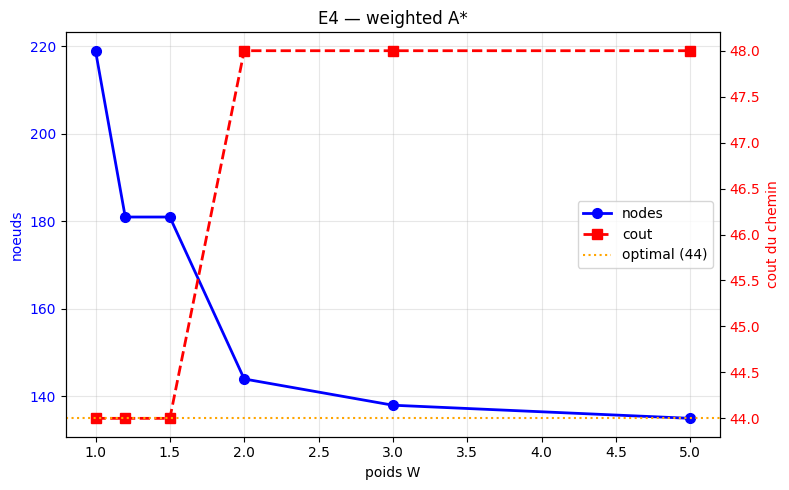

In [7]:
env  = make_hard_grid()
ws   = [1.0, 1.2, 1.5, 2.0, 3.0, 5.0]
opt  = graph_search(env, search_type='A*')['cost']

costs, nodes = [], []
for w in ws:
    r = graph_search(env, search_type='A*', weight=w)
    costs.append(r['cost'])
    nodes.append(r['nodes_developed'])
    sub = (r['cost']-opt)/opt*100
    print(f'W={w:.1f}  cost={r["cost"]}  nodes={r["nodes_developed"]}  subopt={sub:.1f}%')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(ws, nodes, 'bo-', lw=2, ms=7, label='nodes')
ax1.set_xlabel('poids W'); ax1.set_ylabel('noeuds', color='b')
ax1.tick_params(axis='y', labelcolor='b'); ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ws, costs, 'rs--', lw=2, ms=7, label='cout')
ax2.axhline(opt, color='orange', ls=':', lw=1.5, label=f'optimal ({opt})')
ax2.set_ylabel('cout du chemin', color='r')
ax2.tick_params(axis='y', labelcolor='r')

l1,lb1 = ax1.get_legend_handles_labels()
l2,lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='center right')
ax1.set_title('E4 — weighted A*')
plt.tight_layout()
plt.savefig('../results/E4_weighted_astar/E4_weighted_astar.png', dpi=120)
plt.show()


## Phase 3 — construction de P et evolution de pi(n)


P stochastic: True
P shape: (203, 203)
n=  0  P(goal)=0.0000
n= 22  P(goal)=0.0000
n= 44  P(goal)=0.0334
n= 54  P(goal)=0.7015
n= 74  P(goal)=0.7446
n= 88  P(goal)=0.7448


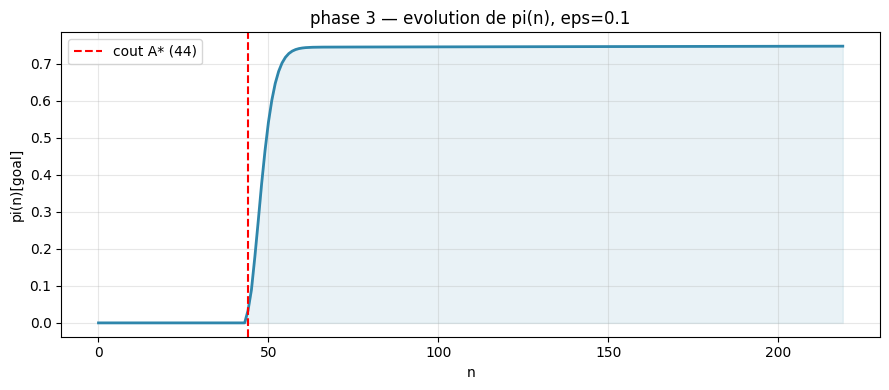

In [8]:
env = make_medium_grid()
r   = graph_search(env, search_type='A*')
pol = make_policy(r['path'], env)
eps = 0.1
opt = r['cost']

P, states, sid = build_transition_matrix(env, pol, eps=eps)
print('P stochastic:', np.allclose(P.sum(axis=1), 1.0))
print('P shape:', P.shape)

pi0 = np.zeros(len(states))
pi0[sid[env.start]] = 1.0
gi  = sid[env.goal]

ns = range(0, opt*5)
probs = [float((pi0 @ np.linalg.matrix_power(P,n))[gi]) for n in ns]

# quelques valeurs
for n in [0, opt//2, opt, opt+10, opt+30, opt*2]:
    if n < len(probs):
        print(f'n={n:3d}  P(goal)={probs[n]:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(ns), probs, color='#2e86ab', lw=2)
ax.fill_between(list(ns), probs, alpha=0.1, color='#2e86ab')
ax.axvline(opt, color='r', ls='--', lw=1.5, label=f'cout A* ({opt})')
ax.set_xlabel('n'); ax.set_ylabel('pi(n)[goal]')
ax.set_title(f'phase 3 — evolution de pi(n), eps={eps}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/Phase3_markov_chain/Phase3_pi_evolution.png', dpi=120)
plt.show()


## Phase 4 — classes de communication et absorption


eps=0.0  classes=202  rec=2  trans=200
eps=0.1  classes=32  rec=1  trans=31
  P(goal|start)=1.0000  E[steps]=4147.9
eps=0.2  classes=32  rec=1  trans=31
  P(goal|start)=1.0000  E[steps]=782.7


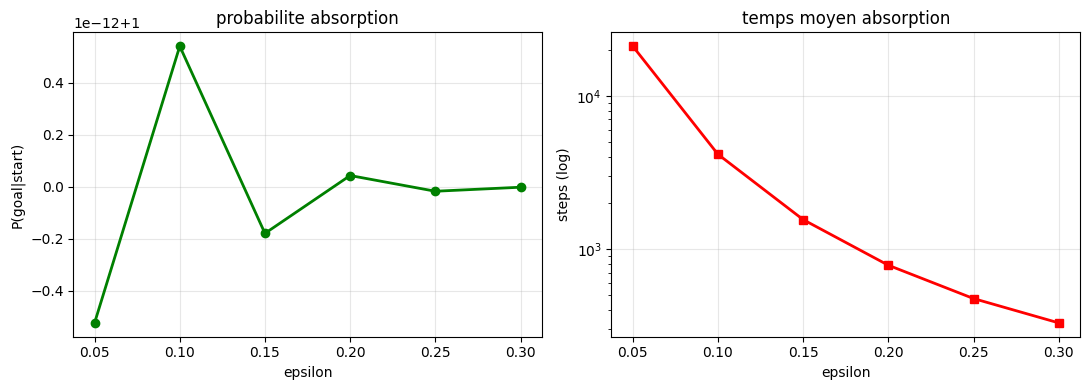

In [9]:
env = make_medium_grid()
r   = graph_search(env, search_type='A*')
pol = make_policy(r['path'], env)

for eps in [0.0, 0.1, 0.2]:
    P, states, _ = build_transition_matrix(env, pol, eps=eps)
    cls = comm_classes(P, states)
    nr  = sum(1 for c in cls if c['type']=='recurrent')
    nt  = sum(1 for c in cls if c['type']=='transient')
    print(f'eps={eps}  classes={len(cls)}  rec={nr}  trans={nt}')
    if eps > 0:
        ap = absorb_prob(P, states, env.goal)
        et = expected_steps(P, states, env.goal)
        print(f'  P(goal|start)={ap[env.start]:.4f}  E[steps]={et[env.start]:.1f}')

# courbe d'absorption selon epsilon
eps_range = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
ap_vals, et_vals = [], []
for eps in eps_range:
    P2, st2, _ = build_transition_matrix(env, pol, eps=eps)
    ap_vals.append(absorb_prob(P2, st2, env.goal)[env.start])
    et_vals.append(expected_steps(P2, st2, env.goal)[env.start])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(eps_range, ap_vals, 'go-', lw=2, ms=6)
ax1.set_xlabel('epsilon'); ax1.set_ylabel('P(goal|start)')
ax1.set_title('probabilite absorption'); ax1.grid(alpha=0.3)

ax2.plot(eps_range, et_vals, 'rs-', lw=2, ms=6)
ax2.set_xlabel('epsilon'); ax2.set_ylabel('steps (log)')
ax2.set_title('temps moyen absorption'); ax2.set_yscale('log'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/Phase4_absorption/Phase4_absorption.png', dpi=120)
plt.show()


## Phase 5 — simulation Monte Carlo


eps=0.0  succes=1.0000  moy=44.0  med=44
eps=0.1  succes=0.7436  moy=49.8  med=48
eps=0.2  succes=0.6853  moy=66.5  med=56
eps=0.3  succes=0.7249  moy=96.7  med=70


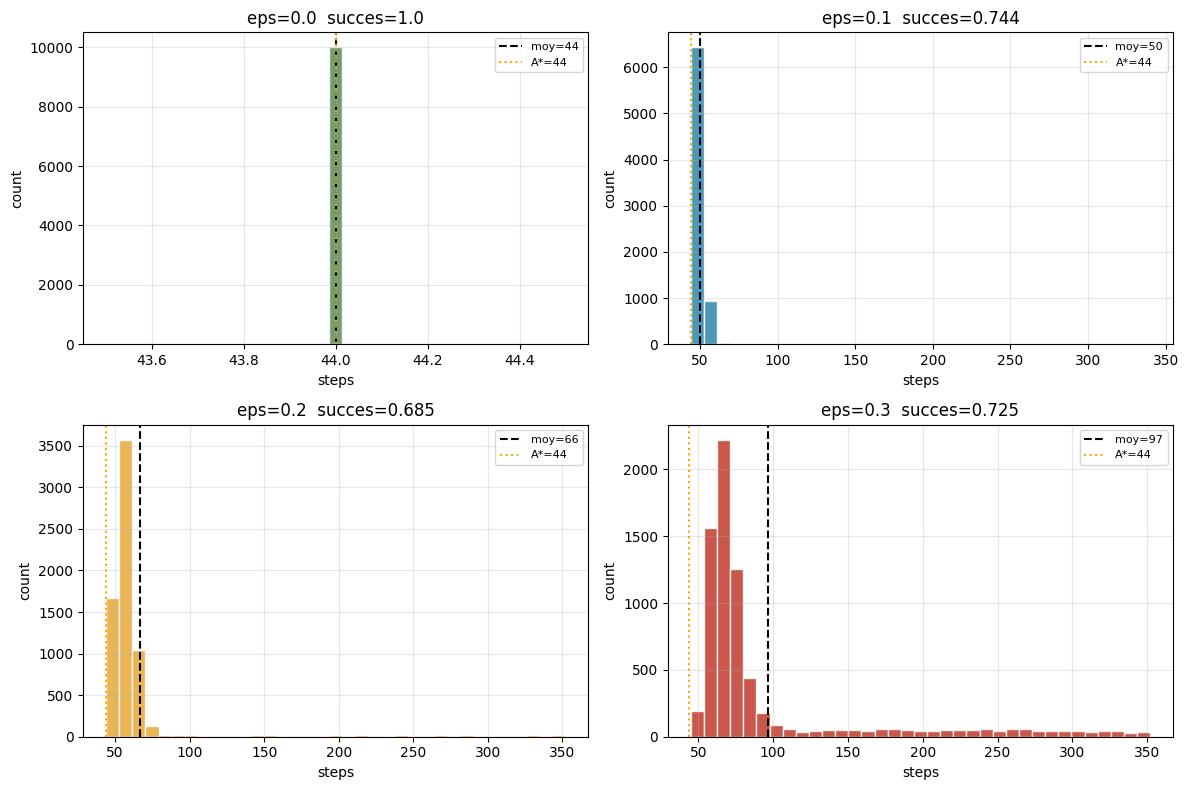

In [10]:
env  = make_medium_grid()
r    = graph_search(env, search_type='A*')
pol  = make_policy(r['path'], env)
opt  = r['cost']

eps_list = [0.0, 0.1, 0.2, 0.3]
sims = []

for eps in eps_list:
    P, states, _ = build_transition_matrix(env, pol, eps=eps)
    rate, avg, times = monte_carlo(P, states, env.start, env.goal,
                                   N=10000, max_steps=opt*8)
    med = float(np.median(times)) if times else 0
    print(f'eps={eps}  succes={rate:.4f}  moy={avg:.1f}  med={med:.0f}')
    sims.append((eps, times, avg))

colors = ['#5b8c5a','#2e86ab','#e8a838','#c0392b']
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ax, (eps, times, avg), col in zip(axs.flat, sims, colors):
    if times:
        ax.hist(times, bins=35, color=col, edgecolor='white', alpha=0.85)
        ax.axvline(avg, color='k',      ls='--', lw=1.5, label=f'moy={avg:.0f}')
        ax.axvline(opt, color='orange', ls=':',  lw=1.5, label=f'A*={opt}')
        ax.set_title(f'eps={eps}  succes={round(len(times)/10000,3)}')
        ax.set_xlabel('steps'); ax.set_ylabel('count')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/Phase5_monte_carlo/Phase5_histograms.png', dpi=120)
plt.show()
